<a href="https://colab.research.google.com/github/pablillo77/stock-statistical-arbitrage/blob/main/Stock_anomalies_detection_with_PCA_teaching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock anomaly detection with PCA (statistical arbitrage)

The idea in one paragraph: most of a stock's daily move is not about the stock —
it's the market, its sector, interest rates, etc. If we strip out those common
("systematic") movements, what's left over is the **residual**: the part of the
return that belongs to that stock alone. Residuals tend to hover around zero.
When a stock's accumulated residual drifts unusually far from its own average,
it often drifts back (**mean reversion**) — and that's a tradeable signal.

The pipeline:

1. Download ~2 years of daily prices for a 38-stock, 5-sector universe
2. Run **PCA** on the return correlation matrix to find the common factors
3. Regress each stock's returns on those factors → get the residuals
4. Accumulate recent residuals and compute an **s-score** (how many standard
   deviations away from its mean the accumulated residual is)
5. Estimate the **half-life** of mean reversion (how fast it snaps back)
6. Flag LONG / SHORT candidates, check the market regime, and pull recent
   headlines for each candidate (a signal caused by news usually won't revert)

This is a decision-support tool, not an auto-trader. Every signal still needs
a human sanity check.

## 0. Setup

Only needed once per Colab runtime. `ipympl` enables the interactive (rotatable)
3D plot near the end — everything else works without it.

In [ ]:
!pip install yfinance ipympl --quiet

# Colab blocks third-party widgets by default; this turns them on so the
# 3D scatter can be rotated. Outside Colab it's a no-op.
try:
    from google.colab import output as _colab_output  # type: ignore
    _colab_output.enable_custom_widget_manager()
except Exception:
    pass

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.1 MB/s eta 0:00:00


In [ ]:
import warnings
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

## 1. Configuration

The universe matters. PCA finds the directions along which stocks move
*together*, so a diverse universe gives a richer factor structure:

- **PC1** is almost always "the market" — everything loads on it
- **PC2, PC3** typically split tech vs defensives, or cyclicals vs rate-sensitives
- Higher PCs capture finer sector tilts

With 5 distinct sectors here, the real structure has roughly 5–7 dimensions,
so `N_FACTORS = 8` keeps a small buffer. The scree plot in section 8 shows
whether that choice is right.

Key parameters:

| Parameter | Meaning |
|---|---|
| `WINDOW` | lookback (trading days) for the PCA and the regressions |
| `ACCUM_WINDOW` | how many recent residual days go into the s-score |
| `S_OPEN` | how extreme (in σ) the deviation must be to flag a candidate |
| `HL_MIN`, `HL_MAX` | accept only reversion speeds in this range: faster than 5d is usually noise, slower than 30d isn't worth the wait |

In [ ]:
TICKERS = [
    # tech / software / semis
    "AAPL", "MSFT", "GOOGL", "META", "AMZN", "NVDA", "AMD", "INTC",
    "AVGO", "QCOM", "TXN", "MU", "ADBE", "CRM", "ORCL", "NOW", "INTU",
    "CSCO", "IBM", "ACN", "SHOP", "NFLX", "PYPL", "UBER",
    # pharma / GLP-1
    "LLY", "NVO", "PFE", "ABBV", "MRK",
    # nuclear utilities (AI power trade)
    "CEG", "VST",
    # oil & gas
    "XOM", "CVX", "COP",
    # banks
    "JPM", "BAC", "WFC", "GS",
]
# 38 names, 5 sectors

WINDOW         = 252   # PCA / regression lookback (1 trading year)
N_FACTORS      = 8     # K: number of principal components (factors) kept
ACCUM_WINDOW   = 60    # days of residuals accumulated for the s-score
LOOKBACK_YEARS = 2     # price history to download

S_OPEN  = 1.25         # |s-score| threshold to flag a candidate
HL_MIN  = 5            # min acceptable half-life (days)
HL_MAX  = 30           # max acceptable half-life (days)

PLOT_TOP_N = 4         # candidate residual paths to chart

## 2. Download prices and compute log returns

We use **log returns**, `r_t = ln(P_t / P_{t-1})`, instead of simple percentage
returns. Two reasons: they add up over time (the sum of daily log returns is
the log return of the whole period, which makes "accumulated residuals" clean
to define), and for daily moves they're numerically almost identical to
percentage returns anyway.

In [ ]:
end   = datetime.today()
start = end - timedelta(days=int(LOOKBACK_YEARS * 365.25) + 30)

print(f"Downloading {len(TICKERS)} tickers from {start.date()} to {end.date()} ...")
prices = yf.download(
    tickers=TICKERS, start=start, end=end,
    auto_adjust=True, progress=False, group_by="column",
)["Close"]

prices = prices.dropna(how="all").ffill(limit=1)   # tolerate a single missing day
print(f"  prices shape: {prices.shape[0]} days x {prices.shape[1]} tickers")
print(f"  last date:    {prices.index[-1].date()}")

# log returns
returns = np.log(prices).diff().iloc[1:]

  prices shape: 520 days x 38 tickers
  last date:    2026-07-08


## 3. Slice the analysis window

We work on the most recent `WINDOW` days. Any ticker with more than 2% of days
missing in that window (new listings, data gaps) is dropped — a ragged panel
would poison the covariance matrix.

In [ ]:
win_raw = returns.iloc[-WINDOW:]
missing = win_raw.isna().mean()
keep    = missing[missing <= 0.02].index.tolist()
dropped = [t for t in win_raw.columns if t not in keep]
win     = win_raw[keep].dropna(how="any")

print(f"Window: last {len(win)} days, {len(keep)} tickers kept"
      + (f", dropped: {dropped}" if dropped else ""))

Window: last 252 days, 38 tickers kept


## 4. PCA: find the common factors

**Step by step:**

1. **Standardize** each stock's returns (subtract mean, divide by std). Now
   every stock has unit variance, so a volatile stock like NVDA doesn't
   dominate the analysis just by being volatile.
2. The covariance matrix of standardized returns **is** the correlation
   matrix. We diagonalize it: `C = V Λ Vᵀ`.
3. Each **eigenvector** is a portfolio of stocks (an *eigenportfolio*); its
   **eigenvalue** says how much of the total variance that portfolio explains.
   We keep the top `K` and call them our factors.
4. **Factor returns** `F = Z · W`: for each day, how much did each
   eigenportfolio move.

One technical detail: an eigenvector multiplied by −1 is still the same
eigenvector, so `eigh` can return them with arbitrary sign flips from run to
run. We fix a sign convention (largest-weight component positive) purely so
the loadings are stable and readable — it changes nothing mathematically.

In [ ]:
mu    = win.mean()
sigma = win.std()
Z     = (win - mu) / sigma           # standardized returns: mean 0, variance 1
C     = Z.cov().values               # = correlation matrix (Z is z-scored)

# eigendecomposition; eigh returns eigenvalues in ascending order -> reverse
eigvals, eigvecs = np.linalg.eigh(C)
order            = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

W_pc = eigvecs[:, :N_FACTORS]        # (N stocks x K factors) loadings

# sign convention: make the largest-|weight| component of each PC positive
for k in range(N_FACTORS):
    if W_pc[np.argmax(np.abs(W_pc[:, k])), k] < 0:
        W_pc[:, k] *= -1

all_var_ratios = eigvals / eigvals.sum()
var_explained  = all_var_ratios[:N_FACTORS].sum()
print(f"PCA: K={N_FACTORS} factors explain {var_explained:.1%} of variance")
print(f"  per-factor: {[f'{v:.1%}' for v in all_var_ratios[:N_FACTORS]]}")

# factor returns: project standardized returns onto the eigenvectors
F = pd.DataFrame(
    Z.values @ W_pc,
    index=win.index,
    columns=[f"PC{i+1}" for i in range(N_FACTORS)],
)

PCA: K=8 factors explain 62.6% of variance
  per-factor: ['18.1%', '13.0%', '8.2%', '6.9%', '5.5%', '4.2%', '3.7%', '3.0%']


## 5. Factor regression → residuals

For each stock we fit, by ordinary least squares over the window:

$$r_{i,t} = \alpha_i + \sum_{k=1}^{K} \beta_{i,k} \, F_{k,t} + \varepsilon_{i,t}$$

- the **betas** are the stock's exposures to each factor
- the **residual** ε is what the factors *cannot* explain — the stock-specific
  part we actually care about

Implementation note: `np.linalg.lstsq` accepts a 2-D target, so one call fits
all 38 regressions at once (they all share the same design matrix). Identical
result to looping over tickers, ~18x faster.

In [ ]:
X_design = np.column_stack([np.ones(len(F)), F.values])   # (T, K+1): intercept + factors

coefs, *_ = np.linalg.lstsq(X_design, win.values, rcond=None)   # (K+1, N)

residuals = pd.DataFrame(
    win.values - X_design @ coefs,
    index=win.index, columns=win.columns,
)
betas = coefs[1:].T    # (N, K) factor loadings; reused later for the 3D plot

## 6. s-score and half-life: measuring the anomaly

**Accumulated residual.** Sum the last `ACCUM_WINDOW` daily residuals into a
running total `X_t`. If a stock quietly underperforms its factor-predicted
return day after day, the daily residuals are tiny but `X_t` drifts steadily
down — accumulation makes slow drifts visible.

**s-score.** How unusual is today's `X_t` relative to its own recent history?

$$s = \frac{X_{today} - \bar{X}}{\sigma_X}$$

`s = -2` means the stock sits 2 standard deviations *below* where its factor
exposures say it should be → potential **LONG** (bet on reversion up).

**Half-life.** A big deviation is only tradeable if it actually reverts, and
fast enough. We model `X_t` as an Ornstein–Uhlenbeck (mean-reverting) process,
whose discrete form is an AR(1): `X_t = a + b·X_{t-1} + noise`.

- `b < 1` → mean-reverting; speed κ = −ln(b); **half-life = ln(2)/κ**
  (days needed to close half the gap)
- `b ≥ 1` → not reverting at all (random walk or trending) → discard

In [ ]:
def ar1_half_life(x: np.ndarray) -> float:
    """Half-life of mean reversion via an AR(1) fit: X_t = a + b*X_{t-1}.

    half_life = ln(2) / -ln(b). Returns NaN when the series is not
    mean-reverting (b outside (0, 1)) or too short to fit.
    """
    if len(x) < 10 or np.std(x[:-1]) < 1e-12:
        return np.nan
    slope, _ = np.polyfit(x[:-1], x[1:], 1)   # b = slope of X_t vs X_{t-1}
    if slope <= 0 or slope >= 1:
        return np.nan
    return float(np.log(2) / -np.log(slope))


rows = []
for tk in residuals.columns:
    eps = residuals[tk].dropna()
    if len(eps) < ACCUM_WINDOW:
        continue
    X_t = eps.iloc[-ACCUM_WINDOW:].cumsum()          # accumulated residual

    s_score   = (X_t.iloc[-1] - X_t.mean()) / X_t.std() if X_t.std() > 0 else 0.0
    half_life = ar1_half_life(X_t.values)

    rows.append({
        "ticker":      tk,
        "s_score":     s_score,
        "half_life_d": half_life,
        "last_ret_%":  win[tk].iloc[-1] * 100,       # today's raw return, for context
    })

watch = pd.DataFrame(rows)

## 7. Signal logic and market regime

A candidate must pass **both** filters:

- `|s| > S_OPEN` — the deviation is large enough to matter
- `HL_MIN ≤ half-life ≤ HL_MAX` — and it historically reverts at a usable speed

Sign convention: `s < −S_OPEN` → **LONG** (below fair value, expect a bounce);
`s > +S_OPEN` → **SHORT**.

**Regime check.** When the *average pairwise correlation* across the universe
spikes (panic selloffs, macro shocks), everything moves together: the factors
absorb nearly all variance and the residuals become noise. In that regime the
signals are unreliable — the tool tells you so rather than pretending.

In [ ]:
def classify(row) -> str:
    s, hl = row["s_score"], row["half_life_d"]
    if pd.isna(hl) or not (HL_MIN <= hl <= HL_MAX):
        return "-"                      # no usable reversion -> no trade
    if s < -S_OPEN:
        return "LONG"
    if s > S_OPEN:
        return "SHORT"
    return "-"

watch["signal"] = watch.apply(classify, axis=1)
watch = watch.sort_values("s_score", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

# regime: mean of the upper triangle of the correlation matrix
corr_matrix       = win.corr().values
upper             = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
mean_pairwise_rho = float(np.mean(upper))
regime = ("CALM   - residual signal usable" if mean_pairwise_rho < 0.4 else
          "NORMAL - proceed with usual filters" if mean_pairwise_rho < 0.6 else
          "STRESSED - high correlation, residuals likely noise, be skeptical")

# ---- daily watchlist ----
print("=" * 70)
print(f"   DAILY WATCHLIST - {win.index[-1].date()}")
print("=" * 70)
print(f"  window={WINDOW}d   K={N_FACTORS}   var explained={var_explained:.1%}")
print(f"  universe={len(win.columns)} names   accum_window={ACCUM_WINDOW}d")
print(f"  regime: rho={mean_pairwise_rho:.2f} -> {regime}")
print(f"  thresholds: |s|>{S_OPEN}  hl in [{HL_MIN},{HL_MAX}]d")
print("-" * 70)
print(watch.to_string(index=False))

candidates = watch[watch["signal"].isin(["LONG", "SHORT"])]
print("-" * 70)
print(f"  -> {len(candidates)} candidate(s) today: "
      + (", ".join(f"{r.ticker}({r.signal})" for r in candidates.itertuples()) if len(candidates) else "none"))
print("=" * 70)

   DAILY WATCHLIST - 2026-07-08
  window=252d   K=8   var explained=62.6%
  universe=38 names   accum_window=60d
  regime: rho=0.12 -> CALM   - residual signal usable
  thresholds: |s|>1.25  hl in [5,30]d
----------------------------------------------------------------------
ticker  s_score  half_life_d  last_ret_% signal
    GS   -2.209       11.966      -1.772   LONG
  ORCL   -2.146       11.653      -2.522   LONG
  ABBV    1.989       14.900      -0.405  SHORT
   IBM    1.910       20.784      -1.488  SHORT
   PFE   -1.756      198.424       0.683      -
   VST    1.717       11.987      -1.998  SHORT
   ACN   -1.664       29.717      -2.399   LONG
   TXN    1.555        2.195       4.213      -
   NVO    1.526       16.561      -0.809  SHORT
   NOW    1.496      935.841      -3.802      -
   AMD    1.491       14.603      -1.034  SHORT
 GOOGL   -1.479       52.908      -1.632      -
  AMZN   -1.256        3.217      -1.542      -
   CEG   -1.198       17.093       0.460      -
  IN

### Residual paths of the top candidates

Each panel is one stock's accumulated residual `X_t` over the last
`ACCUM_WINDOW` days. Dashed line = its mean, dotted lines = ±`S_OPEN`·σ (the
trigger bands). A good LONG candidate shows the line dipping below the lower
band; the trade thesis is that it climbs back toward the dashed line.

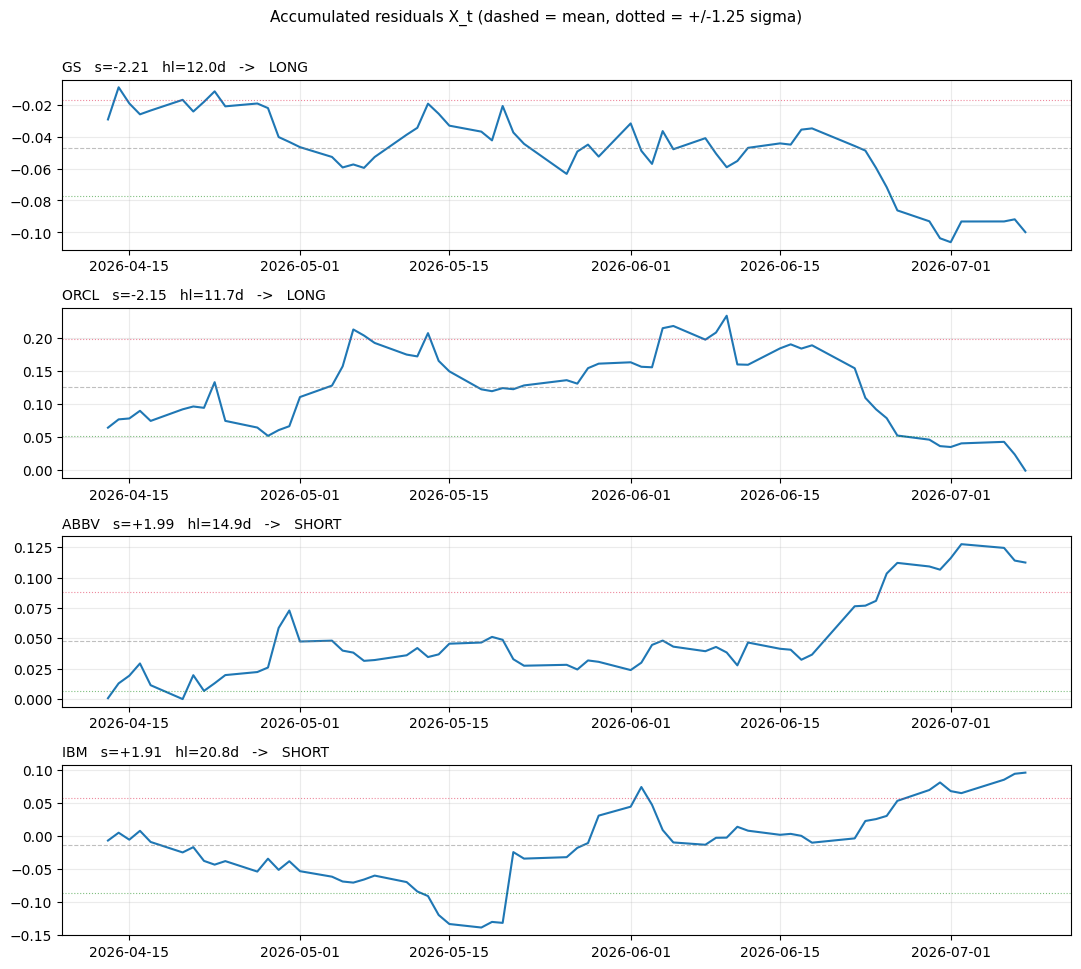

In [ ]:
to_plot = candidates.head(PLOT_TOP_N) if len(candidates) else watch.head(PLOT_TOP_N)

n = len(to_plot)
if n > 0:
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.4 * n), squeeze=False)
    for ax, (_, r) in zip(axes[:, 0], to_plot.iterrows()):
        X_t = residuals[r["ticker"]].iloc[-ACCUM_WINDOW:].cumsum()
        ax.plot(X_t.index, X_t.values, lw=1.5)
        ax.axhline(X_t.mean(), color="gray", ls="--", alpha=0.5, lw=0.8)
        ax.axhline(X_t.mean() + S_OPEN * X_t.std(), color="crimson", ls=":", alpha=0.5, lw=0.8)
        ax.axhline(X_t.mean() - S_OPEN * X_t.std(), color="green", ls=":", alpha=0.5, lw=0.8)
        ax.set_title(
            f"{r['ticker']}   s={r['s_score']:+.2f}   "
            f"hl={r['half_life_d']:.1f}d   ->   {r['signal']}",
            fontsize=10, loc="left",
        )
        ax.grid(alpha=0.25)
    plt.suptitle(f"Accumulated residuals X_t (dashed = mean, dotted = +/-{S_OPEN} sigma)",
                 fontsize=11, y=1.005)
    plt.tight_layout()
    plt.show()

## 8. Scree plot: was K a good choice?

The scree plot shows how much variance each principal component explains
(bars) and the running total (line). How to read it:

- Look for the **elbow** — the point where extra components stop adding much
- If the cumulative line plateaus well before `K`, you're keeping noise
- If it's still climbing steeply at `K`, you're under-explaining and real
  factor movement will leak into the residuals (fake signals)
- **PC1 > 60%** on its own is a stress indicator: a one-factor world

MARKET REGIME - 2026-07-08
  mean pairwise correlation = 0.116
  regime: CALM   - residual signal usable
  PC1 alone explains 18.1% of variance


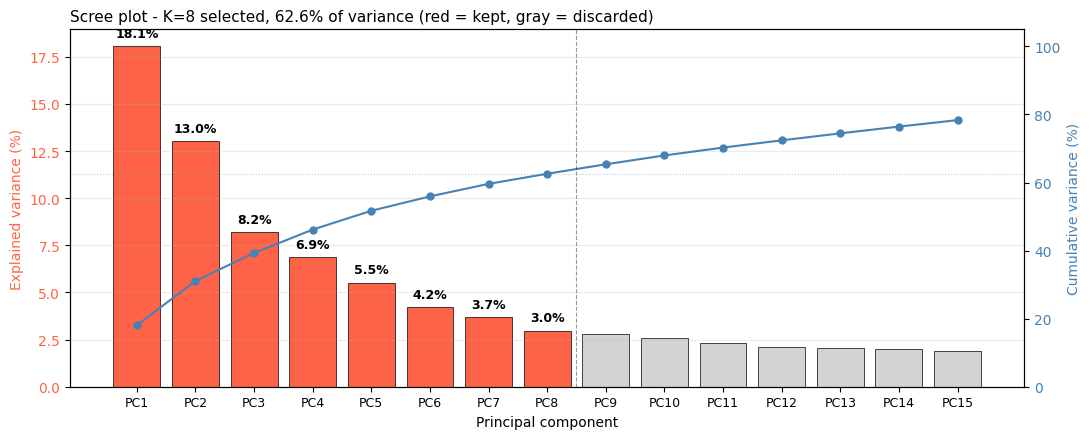

Per-component breakdown:
  * PC1   18.05%   cumulative 18.05%
  * PC2   13.03%   cumulative 31.09%
  * PC3    8.20%   cumulative 39.29%
  * PC4    6.88%   cumulative 46.17%
  * PC5    5.53%   cumulative 51.69%
  * PC6    4.22%   cumulative 55.92%
  * PC7    3.69%   cumulative 59.60%
  * PC8    2.97%   cumulative 62.57%
    PC9    2.77%   cumulative 65.35%
    PC10   2.60%   cumulative 67.95%

  K=8 -> 62.6% of variance explained.


In [ ]:
print(f"MARKET REGIME - {win.index[-1].date()}")
print(f"  mean pairwise correlation = {mean_pairwise_rho:.3f}")
print(f"  regime: {regime}")
print(f"  PC1 alone explains {all_var_ratios[0]:.1%} of variance")

cumulative_ratios = np.cumsum(all_var_ratios)
n_show = min(15, len(all_var_ratios))

fig, ax1 = plt.subplots(figsize=(11, 4.5))

# bars: variance per PC (red = kept, gray = discarded)
colors = ["tomato" if i < N_FACTORS else "lightgray" for i in range(n_show)]
ax1.bar(range(1, n_show + 1), all_var_ratios[:n_show] * 100,
        color=colors, edgecolor="black", linewidth=0.5)
for i in range(N_FACTORS):
    ax1.text(i + 1, all_var_ratios[i] * 100 + 0.5,
             f"{all_var_ratios[i] * 100:.1f}%",
             ha="center", fontsize=9, fontweight="bold")

ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance (%)", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")
ax1.set_xticks(range(1, n_show + 1))
ax1.set_xticklabels([f"PC{i}" for i in range(1, n_show + 1)], fontsize=9)
ax1.grid(axis="y", alpha=0.25)

# cumulative line on a second y-axis
ax2 = ax1.twinx()
ax2.plot(range(1, n_show + 1), cumulative_ratios[:n_show] * 100,
         color="steelblue", marker="o", linewidth=1.5, markersize=5)
ax2.axvline(N_FACTORS + 0.5, color="black", ls="--", alpha=0.4, lw=0.8)
ax2.axhline(cumulative_ratios[N_FACTORS - 1] * 100,
            color="steelblue", ls=":", alpha=0.4, lw=0.8)
ax2.set_ylabel("Cumulative variance (%)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(0, 105)

plt.title(
    f"Scree plot - K={N_FACTORS} selected, "
    f"{cumulative_ratios[N_FACTORS - 1]:.1%} of variance "
    f"(red = kept, gray = discarded)",
    fontsize=11, loc="left",
)
plt.tight_layout()
plt.show()

# text version, easier to grep in saved logs
print("Per-component breakdown:")
for i in range(min(10, len(all_var_ratios))):
    marker = "*" if i < N_FACTORS else " "
    print(f"  {marker} PC{i+1:<2d}  {all_var_ratios[i]*100:5.2f}%   "
          f"cumulative {cumulative_ratios[i]*100:5.2f}%")
print(f"\n  K={N_FACTORS} -> {cumulative_ratios[N_FACTORS-1]*100:.1f}% of variance explained.")

## 9. News check: is the signal clean or event-driven?

The factor model is blind to news. A stock that gaps −6% on bad earnings will
show a huge s-score, but that deviation is a *repricing*, not an anomaly — it
has no reason to revert. (Empirically, on 26-May most high-|s| names that day
had a news catalyst behind them.)

So for every name that fired a signal **or** moved more than 3% today, we pull
the last 48h of headlines from yfinance:

- signal **+ fresh news** → skip, it's event-driven
- signal **+ no news** → likely a clean statistical candidate
- big move **+ no news** → look wider (sector, macro)

In [ ]:
NEWS_RETURN_THRESHOLD     = 3.0   # |today's return| above this -> probably news
NEWS_HEADLINES_PER_TICKER = 4
NEWS_LOOKBACK_HOURS       = 48

need_check = watch[
    (watch["signal"].isin(["LONG", "SHORT"]))
    | (watch["last_ret_%"].abs() >= NEWS_RETURN_THRESHOLD)
].copy()
need_check["reason"] = need_check.apply(
    lambda r: (f"signal={r['signal']}" if r["signal"] in ("LONG", "SHORT")
               else f"moved {r['last_ret_%']:+.1f}% today"),
    axis=1,
)

print("=" * 70)
print(f"   NEWS CHECK - {win.index[-1].date()}")
print("=" * 70)
print(f"  flagged: {len(need_check)} names (signals or |return| >= {NEWS_RETURN_THRESHOLD}%)")
print(f"  headlines from the last {NEWS_LOOKBACK_HOURS}h")
print("-" * 70)

cutoff = datetime.now(timezone.utc) - timedelta(hours=NEWS_LOOKBACK_HOURS)

for _, row in need_check.iterrows():
    tk = row["ticker"]
    print(f"\n  {tk}  ({row['reason']}, s={row['s_score']:+.2f})")

    try:
        items = yf.Ticker(tk).news or []
    except Exception as e:
        print(f"     ! couldn't fetch news ({e})")
        continue

    # yfinance changed its news schema in 2024 -> handle old and new formats
    recent = []
    for it in items:
        content = it.get("content", it)
        title   = content.get("title") or it.get("title")
        pub_raw = content.get("pubDate") or it.get("providerPublishTime")
        publisher = (content.get("provider") or {}).get("displayName") \
                    if isinstance(content.get("provider"), dict) \
                    else it.get("publisher", "")

        # normalize the timestamp (new schema: ISO string, old: unix epoch)
        if isinstance(pub_raw, str):
            try:
                pub = datetime.fromisoformat(pub_raw.replace("Z", "+00:00"))
            except ValueError:
                pub = None
        elif isinstance(pub_raw, (int, float)):
            pub = datetime.fromtimestamp(pub_raw, tz=timezone.utc)
        else:
            pub = None

        if title and pub and pub >= cutoff:
            recent.append((pub, title, publisher))

    recent.sort(reverse=True)   # newest first

    if not recent:
        print(f"     (no headlines in last {NEWS_LOOKBACK_HOURS}h - signal may be clean)")
        continue

    for pub, title, publisher in recent[:NEWS_HEADLINES_PER_TICKER]:
        age_h = (datetime.now(timezone.utc) - pub).total_seconds() / 3600
        src   = f" [{publisher}]" if publisher else ""
        print(f"     - {age_h:4.0f}h ago{src}: {title}")

print("\n" + "-" * 70)
print("  signal + recent news       -> skip, event-driven, won't revert")
print("  signal + no news in 48h    -> likely clean")
print("  >3% move + no news         -> check sector / macro")
print("=" * 70)

   NEWS CHECK - 2026-07-08
  flagged: 15 names (signals or |return| >= 3.0%)
  headlines from the last 48h
----------------------------------------------------------------------

  GS  (signal=LONG, s=-2.21)
     -    1h ago [Simply Wall St.]: Goldman Sachs (GS) Cuts Aluminum Forecast And Turns More Bearish On The Yen
     -    2h ago [Benzinga]: How To Earn $500 A Month From Goldman Sachs Stock Ahead Of Q2 Earnings
     -    3h ago [Zacks]: The PNC Financial Services Group, Inc (PNC) Reports Next Week: Wall Street Expects Earnings Growth
     -    3h ago [24/7 Wall St.]: Goldman Sachs Sees a $2 Trillion Opportunity in Private Markets

  ORCL  (signal=LONG, s=-2.15)
     -    1h ago [24/7 Wall St.]: Prediction: Oracle Will Be the Next Trillion-Dollar Tech Giant
     -    1h ago [Insider Monkey]: Oracle Corporation (ORCL): A Beaten Down Technology Stock to Buy on AI Buildout Opportunities
     -    2h ago [Trefis]: How To Bank 10% On IBM Stock Before Buying A Single Share
     -    2h a

## 10. Stocks in factor space (3D scatter)

Each stock is plotted at its coordinates (β₁, β₂, β₃) — its loadings on the
first three principal components. Think of it as a map of the universe:

- **Along PC1** (market): almost everything is on the same side; the spread
  reflects market beta
- **PC2/PC3**: sectors should separate into visible clusters. If everything
  collapses into one blob, the factor structure is degenerate (universe too
  homogeneous, or K badly chosen)

Why this matters for trading: two stocks that sit **close together** are
*factor twins* — statistically interchangeable in factor terms (AMD/NVDA,
JPM/BAC). When one twin's s-score diverges from the other's, that gap can't
be explained by shared factor exposure, which makes it the cleanest kind of
reversion candidate. The table after the plot ranks the closest pairs.

Marker encoding: size ∝ |s-score| today; thick black edge = firing signal.
Drag the plot to rotate (needs `ipympl` from the setup cell).

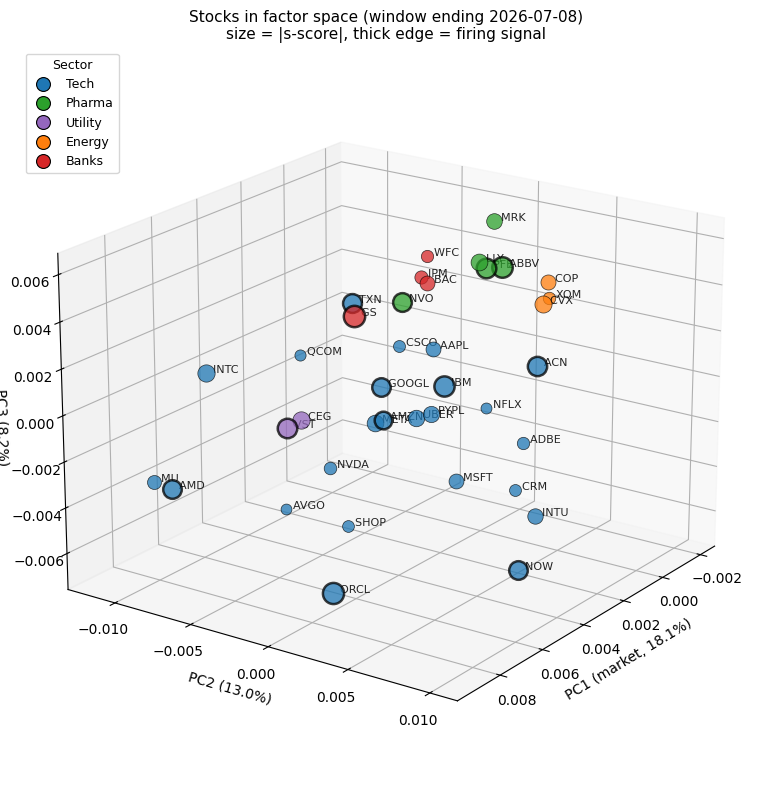


Closest factor-twins (distance in PC1-3 space):
  CVX   - XOM     d=0.00   s(CVX)=+1.15   s(XOM)=-0.26   ds=+1.41
  LLY   - PFE     d=0.00   s(LLY)=+1.09   s(PFE)=-1.76   ds=+2.84
  BAC   - JPM     d=0.00   s(BAC)=+0.70   s(JPM)=+0.39   ds=+0.31
  CEG   - VST     d=0.00   s(CEG)=-1.20   s(VST)=+1.72   ds=-2.92
  AMZN  - META    d=0.00   s(AMZN)=-1.26   s(META)=+1.06   ds=-2.31
  COP   - CVX     d=0.00   s(COP)=+0.73   s(CVX)=+1.15   ds=-0.42
  ABBV  - PFE     d=0.00   s(ABBV)=+1.99   s(PFE)=-1.76   ds=+3.74
  BAC   - WFC     d=0.00   s(BAC)=+0.70   s(WFC)=+0.24   ds=+0.46
  big |ds| between twins = strongest reversion candidates


In [ ]:
SECTOR_MAP = {
    **{t: "Tech" for t in
        ["AAPL", "MSFT", "GOOGL", "META", "AMZN", "NVDA", "AMD", "INTC",
         "AVGO", "QCOM", "TXN", "MU", "ADBE", "CRM", "ORCL", "NOW", "INTU",
         "CSCO", "IBM", "ACN", "SHOP", "NFLX", "PYPL", "UBER"]},
    **{t: "Pharma"  for t in ["LLY", "NVO", "PFE", "ABBV", "MRK"]},
    **{t: "Utility" for t in ["CEG", "VST"]},
    **{t: "Energy"  for t in ["XOM", "CVX", "COP"]},
    **{t: "Banks"   for t in ["JPM", "BAC", "WFC", "GS"]},
}
SECTOR_COLORS = {
    "Tech":    "#1f77b4",
    "Pharma":  "#2ca02c",
    "Utility": "#9467bd",
    "Energy":  "#ff7f0e",
    "Banks":   "#d62728",
    "Other":   "#7f7f7f",
}

if N_FACTORS < 3:
    print("Skipped: need N_FACTORS >= 3 for a 3D scatter.")
else:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3D projection)

    # switch to the widget backend so the plot is rotatable in Colab;
    # falls back to a static image if ipympl isn't installed
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is not None:
            ip.run_line_magic("matplotlib", "widget")
    except Exception:
        ip = None

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    s_lookup = watch.set_index("ticker")["s_score"].to_dict()

    for j, tk in enumerate(win.columns):
        sector = SECTOR_MAP.get(tk, "Other")
        s_val  = s_lookup.get(tk, 0.0)
        size   = 60 + 80 * min(abs(s_val), 3.0)        # bigger = more extreme today
        edge_w = 1.8 if abs(s_val) > S_OPEN else 0.5   # thick edge = firing signal

        ax.scatter(
            betas[j, 0], betas[j, 1], betas[j, 2],
            c=SECTOR_COLORS[sector], s=size, alpha=0.75,
            edgecolors="black", linewidths=edge_w,
        )
        ax.text(betas[j, 0], betas[j, 1], betas[j, 2], f"  {tk}",
                fontsize=8, alpha=0.85)

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w", label=sec,
                   markerfacecolor=col, markeredgecolor="black",
                   markeredgewidth=0.8, markersize=10)
        for sec, col in SECTOR_COLORS.items()
        if any(SECTOR_MAP.get(t) == sec for t in win.columns)
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9,
              title="Sector", title_fontsize=9)

    ax.set_xlabel(f"PC1 (market, {all_var_ratios[0]*100:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({all_var_ratios[1]*100:.1f}%)", fontsize=10)
    ax.set_zlabel(f"PC3 ({all_var_ratios[2]*100:.1f}%)", fontsize=10)
    ax.set_title(
        f"Stocks in factor space (window ending {win.index[-1].date()})\n"
        f"size = |s-score|, thick edge = firing signal",
        fontsize=11,
    )
    ax.view_init(elev=20, azim=35)
    plt.tight_layout()
    plt.show()

    # back to the inline backend so later plots render normally
    try:
        if ip is not None:
            ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass

# nearest neighbors in PC1-3 space = factor twins
if N_FACTORS >= 3:
    from itertools import combinations
    coords = betas[:, :3]
    dists = {
        (win.columns[i], win.columns[j]): float(np.linalg.norm(coords[i] - coords[j]))
        for i, j in combinations(range(len(win.columns)), 2)
    }
    closest = sorted(dists.items(), key=lambda kv: kv[1])[:8]
    print("\nClosest factor-twins (distance in PC1-3 space):")
    for (a, b), d in closest:
        sa, sb = s_lookup.get(a, 0), s_lookup.get(b, 0)
        print(f"  {a:5s} - {b:5s}   d={d:.2f}   "
              f"s({a})={sa:+.2f}   s({b})={sb:+.2f}   ds={sa - sb:+.2f}")
    print("  big |ds| between twins = strongest reversion candidates")

## 11. Optional: log a daily snapshot to Drive

Uncomment to append today's watchlist to a CSV — after a few weeks you can
check how the signals actually played out. Mount Drive first:
`from google.colab import drive; drive.mount('/content/drive')`

In [ ]:
# snapshot_path = "/content/drive/MyDrive/stat_arb_pca/daily_log.csv"
# log_row = watch.copy()
# log_row["date"] = win.index[-1].date()
# log_row["regime_rho"] = mean_pairwise_rho
# import os
# log_row.to_csv(snapshot_path, mode="a",
#                header=not os.path.exists(snapshot_path), index=False)